In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
day = 1695 # setting
n_components = 10  # you can adjust the number of components as needed

In [3]:
raw_factor = pd.read_parquet(f'../processed_data/Factor_compute_{day}.parquet')
raw_factor.head()

,date_id,time_id,factor_00,factor_01,factor_02,factor_03,factor_04,factor_05,factor_06,factor_07,...,factor_69,factor_70,factor_71,factor_72,factor_73,factor_74,factor_75,factor_76,factor_77,factor_78
0,1695,0,-0.227196,0.064831,0.019914,0.060577,-0.172884,-0.080404,-0.150321,0.251847,...,-0.181165,-0.166344,0.176346,0.086744,-0.570482,-0.570482,0.289976,0.289976,0.024264,0.024264
1,1695,1,0.254459,-0.508919,-0.376437,0.015789,0.117230,0.108009,0.498067,0.221248,...,-0.120362,0.190846,0.095395,0.287082,-0.585820,-0.585820,0.431783,0.390371,0.311068,0.285012
2,1695,2,0.194294,-0.410803,-0.007113,0.034400,-0.336229,0.015173,-0.105956,-0.353478,...,-0.292020,-0.022129,0.046528,0.133327,-0.637156,-0.637156,0.364478,0.371476,0.306879,0.306879
3,1695,3,0.307428,-0.432150,-0.013755,0.068410,0.064030,-0.139116,-0.227657,0.095887,...,-0.174288,-0.059821,0.145604,0.039047,-0.604623,-0.604623,0.306599,0.464864,0.265302,0.265302
4,1695,4,0.023257,-0.044701,-0.025993,0.507552,-0.427883,0.164731,-0.186172,-0.279689,...,-0.195231,0.063199,0.085846,0.127048,-0.636940,-0.636940,0.585417,0.638426,0.440689,0.575011


In [4]:
# split index and feature columns
index_cols = ['date_id', 'time_id']
feature_cols = [col for col in raw_factor.columns if col not in index_cols]

# get the index and feature data
indices = raw_factor[index_cols].copy()
features = raw_factor[feature_cols].copy()

In [5]:
# Standardize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features_scaled[:5,:]

array([[-1.75549921,  0.4900993 ,  0.14006598,  0.47121764, -1.38151171,
        -0.59977026, -1.08940272,  1.95151008,  1.10730705, -1.90343562,
         1.40354464,  0.61969884,  3.42631686, -0.38838725,  0.40024959,
        -4.21964267,  3.92648081, -4.44700311,  1.94243124,  2.62231402,
        -0.10157681,  1.52737198, -3.09934019, -4.20965647,  2.2487625 ,
         1.82259906, -2.36477654, -2.99501558, -2.67269805,  0.33251741,
         0.5123715 ,  2.76264988, -4.15828979, -3.68463767, -1.75686069,
         0.20271726, -0.13875661, -3.17466817, -3.26154336, -4.18939178,
         2.87202516, -4.09162428, -3.92085581,  5.6943918 , -4.27922013,
         2.31152845,  3.7576435 ,  1.65445589,  2.7736132 ,  2.48846067,
        -4.23598502,  2.18745598, -4.26700898, -3.84153552,  2.91940697,
        -4.15370826,  1.06320921,  0.59847509, -3.97670604,  2.90848559,
         2.88537098, -4.04296336,  1.13948464, -0.7307543 ,  1.30140994,
         3.30065109,  2.35649464, -1.78383941, -1.2

In [6]:
# run PCA
pca = PCA()
pca_result = pca.fit_transform(features_scaled)
pca_result[:5,:]

array([[-1.03639260e-01,  8.07122565e-02,  6.33841986e+00,
        -9.58312129e-01,  6.66798365e+00, -4.22061615e+00,
         4.78130882e+00, -6.20143231e+00,  8.45979713e+00,
         3.26141917e+00,  1.07899082e+01,  5.13188048e+00,
         1.98725459e+00,  1.23071672e+00,  8.67803586e-01,
        -1.64370365e+00,  1.18814965e+00, -2.48297766e-02,
        -3.30120314e+00,  2.97015765e+00, -1.03009662e+00,
         1.85802242e+00, -3.82742730e+00,  1.70678354e+00,
         1.52803568e+00, -3.54819088e+00,  2.22536350e+00,
         3.23937361e+00, -2.73412651e+00,  2.68850819e+00,
        -9.06825486e-01,  5.64591972e-01,  2.18154209e+00,
         1.18063785e+00,  3.09561370e+00,  1.52832383e+00,
        -3.05760260e+00, -3.01618135e+00,  1.90599343e-01,
        -5.98967453e-01,  1.79729520e+00, -1.12821862e-01,
        -1.19584922e+00,  9.95457838e-01, -2.41575244e-01,
        -4.57955561e-01, -9.10146446e-01,  2.48073286e+00,
        -1.48795639e-01, -7.92390157e-01,  3.53215486e-0

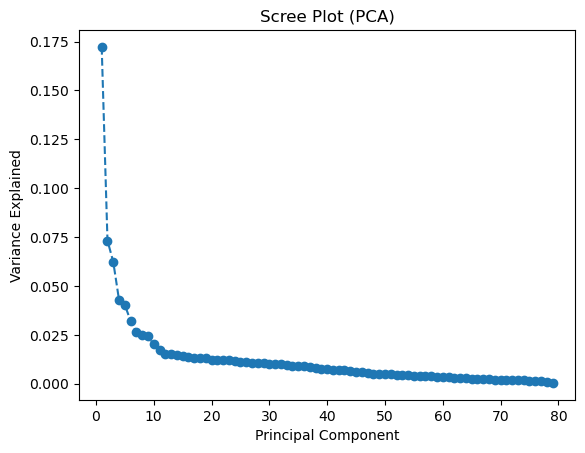

In [7]:
# Scree Plot
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o', linestyle='--')
plt.title('Scree Plot (PCA)')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()

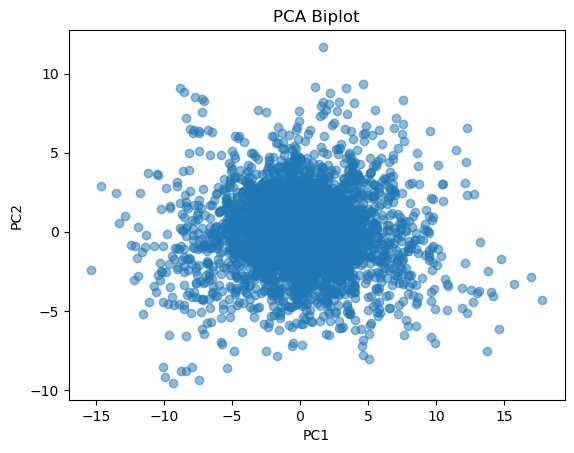

In [8]:
# Biplot (First Two Components)
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Biplot')
plt.show()

In [9]:
pca_loadings = pca.components_.T
pca_loadings

array([[-1.71115908e-03,  2.79071933e-03,  3.46378996e-03, ...,
        -2.37250754e-03,  1.28193174e-03,  1.49102403e-03],
       [-1.64699776e-03,  8.77500036e-03, -1.20252356e-02, ...,
        -1.18076289e-02,  5.19968130e-04,  1.66312785e-03],
       [ 9.90193360e-03, -1.17832242e-03,  4.32147769e-03, ...,
        -3.48370666e-03, -4.56011836e-03,  9.73020214e-05],
       ...,
       [ 9.26050645e-02,  1.89053057e-01,  1.39608322e-01, ...,
         7.31214087e-03, -2.27678943e-02, -9.13348868e-03],
       [ 1.61993737e-01,  1.89051918e-01,  1.37105315e-01, ...,
         1.11004038e-02,  2.19541372e-02, -1.23468792e-02],
       [ 1.12804737e-01,  2.14583542e-01,  1.84441606e-01, ...,
        -2.93906361e-02,  7.44801706e-03,  1.05279314e-02]])

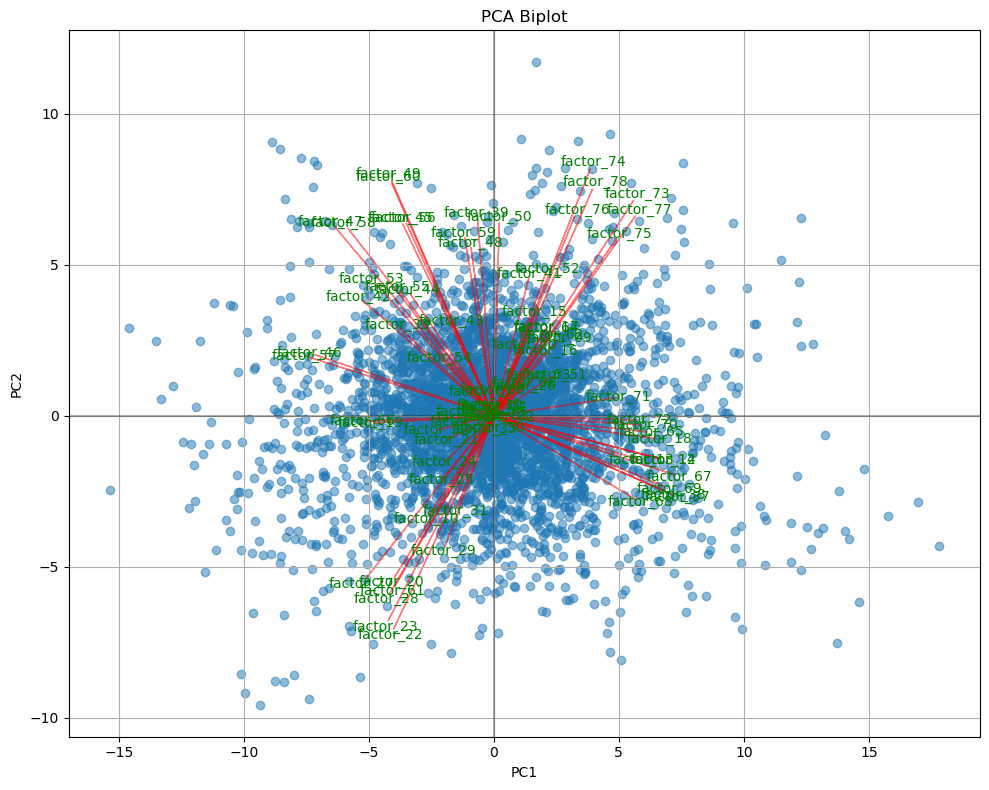

In [10]:
def create_biplot(score, loadings, feature_names, scale=5):
    '''
    该函数创建PCA双标图，展示数据在主成分空间的分布与原始特征的关系：  
    :param score:  主成分得分矩阵（转换后的数据点）
    :param loadings: 载荷矩阵（原始特征对主成分的贡献）
    :param feature_names: 特征名称列表
    :param scale: 载荷矢量的缩放因子（默认为5）
    :return: 
    '''
    # Create figure
    plt.figure(figsize=(10, 8))
    
    # Plot the scores
    plt.scatter(score[:, 0], score[:, 1], alpha=0.5)
    
    # Plot the loading vectors
    for i, (x, y) in enumerate(zip(loadings[:, 0], loadings[:, 1])):
        plt.arrow(0, 0, scale * x* 7, scale * y* 7, color='r', alpha=0.5)
        plt.text(scale * x * 7.2, scale * y * 7.2, feature_names[i], 
                color='g', ha='center', va='center')
    
    # Add labels and title
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA Biplot')
    
    # Add grid and axis lines
    plt.grid(True)
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Get the feature names
feature_names = feature_cols

# Create the biplot with loading vectors
create_biplot(pca_result[:, :2], pca_loadings[:, :2], feature_names)

In [11]:
# create a DataFrame for the PCA loadings(number of components you choose before) 
columns = [f'PC{i+1}' for i in range(n_components)]
pc_df = pd.DataFrame(data=pca_result[:,:n_components], columns=columns)

# combine the PCA result with the index columns
pca_factors = pd.concat([indices.reset_index(drop=True), pc_df], axis=1)
pca_factors

,date_id,time_id,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,1695,0,-0.103639,0.080712,6.338420,-0.958312,6.667984,-4.220616,4.781309,-6.201432,8.459797,3.261419
1,1695,1,1.263302,0.704952,7.011852,0.933417,5.495412,-5.328015,3.786255,-5.120196,9.065758,5.971481
2,1695,2,1.063586,-0.526717,9.691225,-2.784411,4.327114,-3.220950,4.465225,-5.301042,8.130606,7.312849
3,1695,3,-2.296429,-0.192683,11.517618,-1.931100,3.051768,-5.494329,2.450841,-4.344394,4.872303,8.105256
4,1695,4,1.403951,0.893742,12.458288,-3.028513,1.797957,-4.949425,3.053714,-5.111131,4.171001,8.966910
...,...,...,...,...,...,...,...,...,...,...,...,...
3867,1698,963,0.674616,1.487927,-1.316971,-0.657309,1.455302,-1.373983,-1.686958,1.034308,0.273779,-0.176653
3868,1698,964,0.831946,0.332123,0.173629,-0.489235,0.362030,-1.761637,-2.685192,0.706104,0.290691,0.354866
3869,1698,965,0.352564,1.913447,-1.226336,-0.783823,0.235403,-0.210045,-1.767764,0.661634,0.109877,0.183239
3870,1698,966,0.267583,2.425889,-1.301534,-0.828920,0.058406,-0.549771,-2.199832,0.469292,0.169132,0.068607


In [12]:
# Save PCA results
pca_factors.to_parquet(f'../processed_data/PCA_Factor_{day}.parquet')